# Wildfire Risk Prediction

**Goal:** Train a model to predict a property's wildfire risk from its location, using Census socioeconomic data as input features and proximity to historical fire detections as the target.

**Business context:** Wildfire proximity is a key underwriting variable for property insurers, who need to price policies accurately across millions of addresses without site-by-site inspection. This model demonstrates that publicly available Census data — demographics, housing stock, heating fuel — can serve as a cheap, scalable proxy for satellite-derived fire exposure, enabling rapid risk triage for insurance portfolios, real-estate valuations, and municipal planning.

**Approach:**
1. Generate geographically diverse property locations across CONUS
2. Enrich each property with ~850 Census ACS5 features (income, housing, demographics)
3. Calculate proximity to NASA FIRMS satellite fire detections (VIIRS)
4. Train XGBoost and RandomForest regressors to predict `nearest_fire_km`

**Limitations:** Current run uses county-level Census granularity due to hardware constraints. Tract or block-group level would capture finer neighbourhood variation and likely improve results.

In [3]:
import pandas as pd
import load_wildfires
import load_census
import load_properties
import gis
import train
import visualize
import geopandas as gpd

import sqlalchemy as s

from pathlib import Path

from sql_funcs import SQL

from settings import TEST_SAMPLE_SIZE, TEST_N_ITER, TEST_CV, FIGURES_DIR,  MODELS_DIR, DATA_DIR, TARGETS_PARQUET_PATH

TEST_MODE = False


In [4]:
SQL.kill_idle(True)
sql_obj = SQL()


kill_idle: terminated 8 connection(s)


# Generate Property Locations

The first step is to create a geographically diverse sample of property locations across the contiguous United States. Each property needs Census geographic identifiers so it can be joined to socioeconomic features downstream.

We sample 300,000 random coordinates across the contiguous United States using Census [TIGER shapefiles](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) to guarantee every point falls inside a valid census geography. Each property is tagged with a **GEOID** — a hierarchical identifier encoding its state, county, and tract — which serves as the join key for Census feature enrichment in the next step.

The geography-first approach (random point within a randomly selected TIGER polygon) avoids the ~70% failure rate of coordinate-first geocoding, where random lat/lon pairs often land in water, forests, or other uninhabited areas.

In [5]:
props = load_properties.Properties(sql_obj=sql_obj)
properties = props.get_properties_gpd()
cur_count = properties.shape[0]
desired_count = 300000
if cur_count < desired_count:
    diff = desired_count - cur_count
    print(f"Adding {diff} more properties...")
    props.add_random_properties_geo_first(diff)


300000 properties loaded.


# Load Features from US Census

Each property is enriched with ~850 features from the **2023 American Community Survey 5-Year Estimates (ACS5)** via the [Census API](https://www.census.gov/data/developers/data-sets/acs-5year.html). Features span demographics, income, housing stock, heating fuel, and occupancy — all normalized to proportions of their universe totals so that counties of different sizes are comparable.

At county-level granularity, all properties sharing the same county receive identical feature vectors. Finer granularity (tract or block-group) would differentiate neighbourhoods within a county but requires significantly more API calls and storage.

In [6]:

MERGED_PARQUET = DATA_DIR / "merged_properties_census.parquet"

if MERGED_PARQUET.exists():
    print(f"Loading pre-merged data from {MERGED_PARQUET}...")
    combined_gdf = gpd.read_parquet(MERGED_PARQUET)
    print(f"Loaded {len(combined_gdf)} properties with census features.")
else:
    print("No pre-merged file found. Fetching census data from API...")
    census = load_census.CensusData(sql_obj=sql_obj, year=2023, granularity='county')
    combined_gdf = census.merge_census_info(properties)

combined_gdf.head()

Loading pre-merged data from data\merged_properties_census.parquet...
Loaded 300000 properties with census features.


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,B25091_014E,B25091_015E,B25091_016E,B25091_017E,B25091_018E,B25091_019E,B25091_020E,B25091_021E,B25091_022E,B25091_023E
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,0.149341,0.056879,0.033997,0.018242,0.014300,0.010256,0.009368,0.009005,0.024570,0.008219
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,0.097369,0.057454,0.015119,0.017236,0.028122,0.005745,0.000000,0.000000,0.008769,0.000000
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,0.250290,0.074493,0.043701,0.019570,0.014042,0.006302,0.011969,0.013102,0.039002,0.012328
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,0.153632,0.041678,0.019031,0.010505,0.007374,0.005141,0.002201,0.003925,0.011086,0.002309
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,0.156607,0.074042,0.040440,0.022883,0.012523,0.011175,0.007729,0.009077,0.024818,0.002424


# Load Wildfire Data

Wildfire detections from NASA's [FIRMS](https://firms.modaps.eosdis.nasa.gov/) system, using the Visible Infrared Imaging Radiometer Suite (VIIRS) aboard NOAA-21 and Suomi NPP satellites. Each detection is a ~375m pixel with fire radiative power (FRP) in megawatts.

Raw detections are clustered spatiotemporally (DBSCAN: 750m spatial, 3-day temporal) to deduplicate overlapping satellite passes into discrete fire events.

In [7]:

if TARGETS_PARQUET_PATH.exists():
    print(f"Loading pre-computed targets+features from {TARGETS_PARQUET_PATH}...")
    targets_features = gpd.read_parquet(TARGETS_PARQUET_PATH)
    # Reconstruct proximity column list for drop_cols later
    census_cols = [c for c in targets_features.columns if c.startswith("B")]
    proximity_cols = [c for c in targets_features.columns
                      if c not in census_cols and c not in ["geometry", "geoid"]]
    print(f"Loaded {len(targets_features)} rows x {targets_features.shape[1]} cols "
          f"({len(proximity_cols)} proximity features)")
else:
    print("No pre-computed file found. Running wildfire ETL inline...")
    wildfires = load_wildfires.WildfireData(sql_obj=sql_obj)
    proximity_features = gis.calc_all_features_parallel(combined_gdf, wildfires.data, n_jobs=5)
    targets_features = pd.concat([combined_gdf, proximity_features], axis=1)
    proximity_cols = list(proximity_features.columns)
    targets_features.to_parquet(TARGETS_PARQUET_PATH)

targets_features.head()

Loading pre-computed targets+features from data\targets_features.parquet...
Loaded 300000 rows x 870 cols (12 proximity features)


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,4055.170447,54.0,171.0,297.0,909.0,719.961429,2122.26,6608.8860,30538.806250,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,1930.528082,0.0,18.0,126.0,135.0,0.000000,1654.02,5819.5800,2380.935000,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,2865.250712,0.0,0.0,288.0,1233.0,0.000000,0.00,7531.3665,28352.104571,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,569.459042,0.0,0.0,63.0,648.0,0.000000,0.00,717.9300,14553.970179,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,169.973961,0.0,0.0,27.0,108.0,0.000000,0.00,406.0800,1294.245000,31.090475


## Proximity Features (Target Variables)

The proximity features computed from NASA FIRMS detections each capture a different aspect of wildfire exposure. Any of them could serve as the prediction target depending on the use case:

| Target | What it measures | When to use it |
|--------|-----------------|----------------|
| `nearest_fire_km` | Straight-line distance to the single closest fire event | Best default for sparse-fire regions or smaller datasets. Simple to interpret ("this property is X km from the nearest fire") and has high variance across CONUS, giving the model a clear signal to learn. |
| `exp_decay_score` | Sum of exponentially decayed weights across all fires within 50 mi: $\sum w_j \cdot e^{-d_j / h}$ | Preferred target at scale. Captures both proximity *and* density — a property surrounded by many moderate-distance fires scores higher than one near a single isolated fire. Requires geographic diversity in the dataset so the score isn't near-zero everywhere. |
| `kde_density` | Log-transformed Gaussian kernel density estimate of fire activity | Best for producing a smooth, continuous risk surface. Useful when the goal is regional risk mapping rather than property-level prediction, since KDE smooths over individual fire locations. |
| `idw_score` | Inverse-distance-weighted sum: $\sum w_j / d_j^{p}$ | Similar to exponential decay but with a power-law falloff ($p=2$). Fire influence drops off more slowly at long range, making it sensitive to moderately distant fire clusters. Useful when distant-but-large fire complexes should still register as risk. |

For this project we use **`nearest_fire_km`** because the 300k-property dataset provides strong geographic diversity and `nearest_fire_km` offers the most intuitive interpretation for a portfolio context. With a larger or denser dataset, `exp_decay_score` would be the stronger choice as it encodes both how close and how many fires threaten a given property.

# Exploratory Data Analysis

The `visualize.eda()` function generates distribution plots, a missingness heatmap, and a correlation ranking for the top features against the chosen target. Key observations:

- **Target distribution:** `nearest_fire_km` is right-skewed, with most properties within 30 km of a fire detection. The concentration near zero reflects the sampling bias toward populated areas, which tend to sit closer to the wildland-urban interface where satellite fire detections cluster.
- **Missingness:** The vast majority of census features have zero missing values. The few that do show no structured pattern, consistent with Missing Completely At Random (MCAR), and are handled via median imputation during preprocessing.
- **Top correlations:** House heating fuel dominates. Fossil-fuel heating (fuel oil, kerosene) has nearly double the correlation magnitude of electrical heating, acting as a strong regional proxy — fuel-oil homes concentrate in the Northeast, far from the Western/Southern fire belt.

Loading cached EDA figure from figures\eda_summary_nearest_fire_km.png


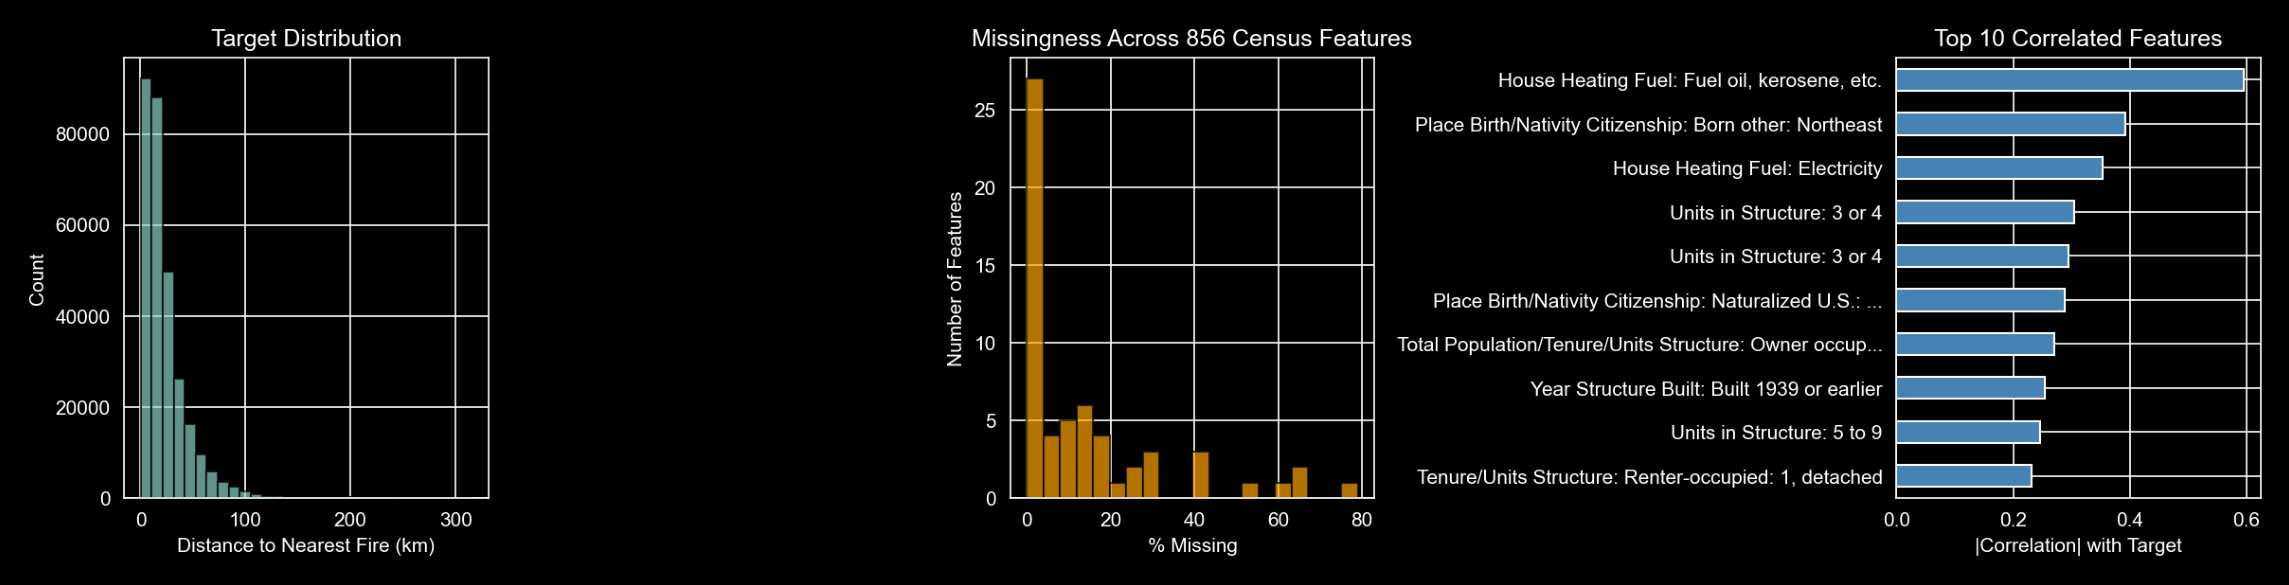

In [6]:
eda = visualize.eda(targets_features, target='nearest_fire_km')

Loading cached EDA figure from figures\eda_summary_exp_decay_score.png


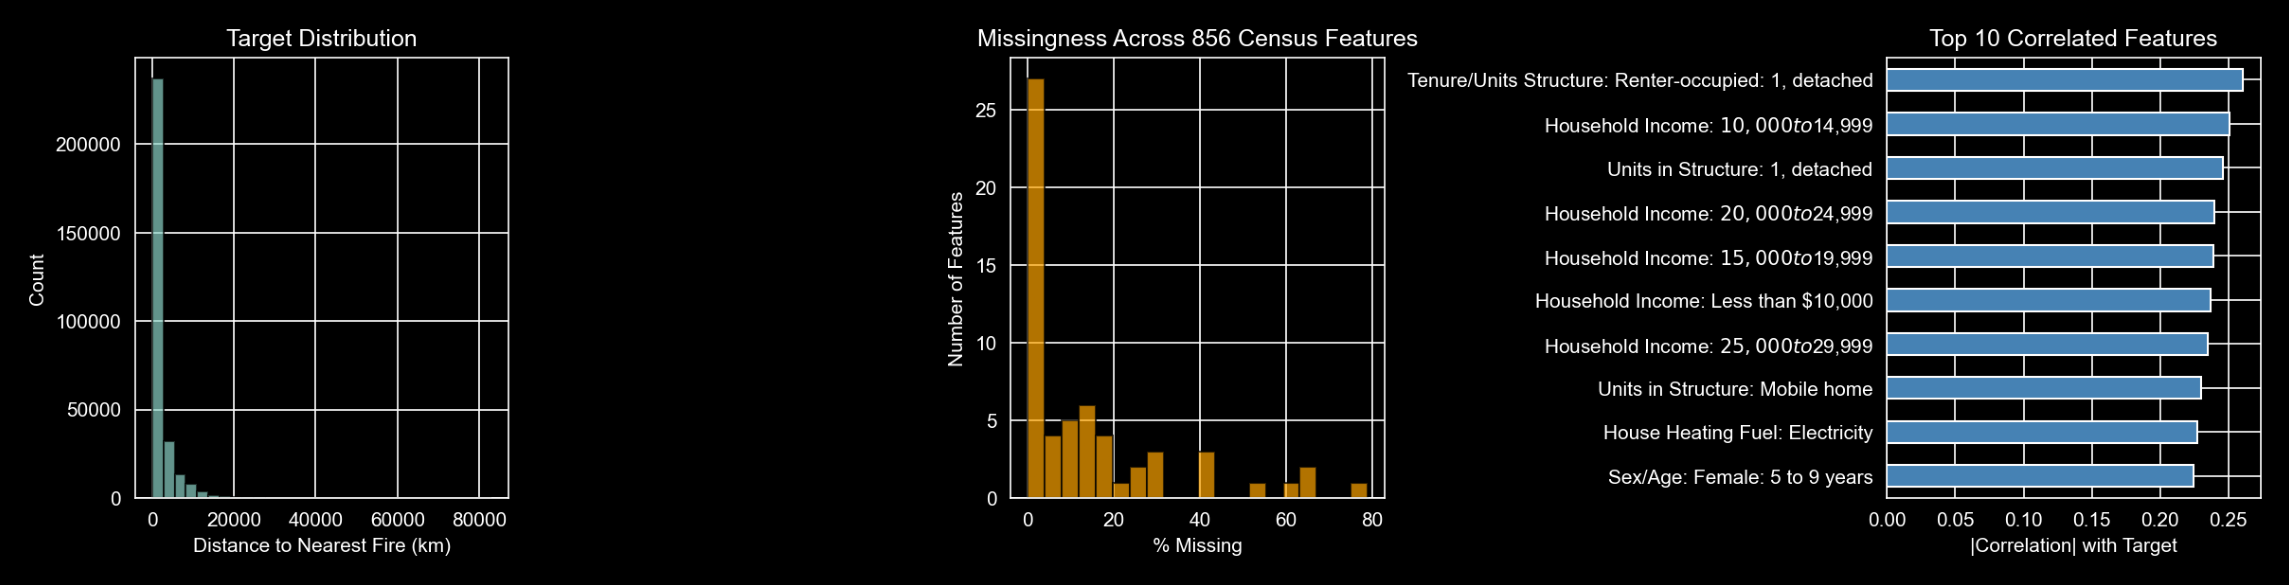

In [7]:
eda = visualize.eda(targets_features, target='exp_decay_score')


# Machine Learning Considerations

## Scoring Methods

**RMSE (Root Mean Squared Error)** is the primary metric. Its quadratic penalty on large errors aligns with the business case: underestimating wildfire risk (predicting a property is far from fires when it isn't) is costly for an insurance company. Because RMSE squares the residuals before averaging, a single prediction that is off by 50 km hurts the score far more than five predictions each off by 10 km — exactly the asymmetry we want when the cost of missing a high-risk property is much greater than slightly mispredicting a safe one.

**MAE (Mean Absolute Error)** complements RMSE by reporting the typical prediction error in the same units as the target (kilometres). Unlike RMSE, MAE weights every error linearly, so it is not dominated by outliers. Comparing the two is informative: when RMSE is much larger than MAE it signals that the model struggles with a tail of large-error cases. Here the gap is modest (~8.7 km RMSE vs ~6.2 km MAE), indicating reasonably consistent predictions without extreme outliers.

**R² (Coefficient of Determination)** measures the fraction of target variance explained by the model. An R² of 0.90 means census features alone capture 90% of the geographic variation in wildfire proximity — strong evidence that socioeconomic and housing patterns are meaningful proxies for fire exposure. R² is unit-free, making it useful for comparing across different target variables or datasets where the raw RMSE scale would differ.


# Data Preprocessing

Before training, the raw feature matrix requires several cleaning steps. Census data contains columns with high missingness (suppressed for small populations), near-perfect correlations (e.g., overlapping demographic breakdowns), and a mix of missingness mechanisms. The pipeline below handles each of these automatically.

## Split into Features/Targets and Preprocess

We use `nearest_fire_km` as the target — the straight-line distance in kilometres from each property to the nearest wildfire detection. All other proximity-derived columns (`exp_decay_score`, fire counts, FRP sums) are dropped so the model sees only census features as inputs.

The preprocessing pipeline:
1. **80/20 train-test split** (240k train, 60k test) with a fixed random seed for reproducibility.
2. **Drop high-NaN columns** (>45% missing) — removes features the Census Bureau suppresses for small populations.
3. **Drop highly correlated features** (|r| > 0.85) — eliminates redundant columns that inflate dimensionality without adding signal.
4. **Adaptive imputation** — columns classified as MCAR get median imputation; MAR columns get iterative (multivariate) imputation to preserve inter-feature correlations.
5. **Standard scaling** — zero-mean, unit-variance normalization for model stability.

After filtering, **556 features** remain from the original ~850.

In [8]:
TARGET_COL =  "nearest_fire_km"# "exp_decay_score"  #

# All proximity features are derived from the same wildfire data — drop them
# so the model only sees census features as inputs.
drop_cols = ["geometry", "geoid"] + [c for c in proximity_cols if c != TARGET_COL]

# Subsample in test mode for fast iteration
ml_data = targets_features
if TEST_MODE:
    ml_data = targets_features.sample(n=TEST_SAMPLE_SIZE, random_state=77)
    print(f"TEST MODE: subsampled to {len(ml_data)} rows")


X_train, X_test, y_train, y_test, feature_names, pipeline = train.preprocess_with_cache(
    ml_data,
    TARGET_COL,
    drop_cols,
    nan_threshold=0.45,
    corr_threshold=0.85,
    mar_corr_threshold=0.1,
    use_cache=not TEST_MODE,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: {y_train.min():.4f} – {y_train.max():.4f}")
print(f"Target std:   {y_train.std():.6f}")
print(f"Target mean:  {y_train.mean():.4f}")

Loading cached preprocessing from preprocess_d270d9dd766b.pkl
  Loaded 556 features from cache
Train: (240000, 556), Test: (60000, 556)
Target range: 0.0329 – 315.4585
Target std:   27.494053
Target mean:  24.4749


In [9]:
# Diagnostic: check if the target has meaningful variance
cv = y_train.std() / y_train.mean() * 100  # coefficient of variation
print(f"Coefficient of variation: {cv:.4f}%")
if cv < 1.0:
    print(
        f"WARNING: Target has near-zero variance (CV={cv:.4f}%). "
        f"All properties are ~{y_train.mean():.1f} km from the nearest fire. "
        f"Models will appear to have perfect accuracy but are not learning meaningful patterns. "
        f"Scale to 300k properties for geographic diversity."
    )

Coefficient of variation: 112.3358%


# Model Training

Due to the VRAM limitations of my local hardware (6 GB VRAM vs 32 GB system RAM), both models are trained on CPU with up to 10 parallel jobs. Hyperparameters are tuned via randomised search with 5-fold cross-validation.

## Load or Train Models

Trained models are cached to disk as pickle artifacts. If a cached model exists for the current target column, it is loaded and evaluated directly; otherwise the training cells below execute a full hyperparameter search.

In [ ]:
RFR_PATH = MODELS_DIR / f"rfr_model_{TARGET_COL}.pkl"
XGB_PATH = MODELS_DIR / f"xgb_model_{TARGET_COL}.pkl"

rfr_model, xgb_model = None, None

if not TEST_MODE:
    if RFR_PATH.exists():
        rfr_artifact = train.load_model(RFR_PATH)
        rfr_model = rfr_artifact["model"]
        print(f"Loaded RF model from {RFR_PATH}")
        rfr_metrics = train.evaluate_model(rfr_model, X_train, X_test, y_train, y_test)
        print(f"\nRF  Test RMSE: {rfr_metrics['test_rmse']:.4f}")

    if XGB_PATH.exists():
        xgb_artifact = train.load_model(XGB_PATH)
        xgb_model = xgb_artifact["model"]
        print(f"Loaded XGB model from {XGB_PATH}")
        xgb_metrics = train.evaluate_model(xgb_model, X_train, X_test, y_train, y_test)
        print(f"XGB Test RMSE: {xgb_metrics['test_rmse']:.4f}")

    else:
        print("No cached models found. Run the training cells below.")
else:
    print(f"TEST MODE: will train on {X_train.shape[0]} rows, "
          f"n_iter={TEST_N_ITER}, cv={TEST_CV}")

Loaded RF model from models\rfr_model_nearest_fire_km.pkl

RF  Test RMSE: 8.7425


## Hyperparameter Search

Each model is tuned via `RandomizedSearchCV` with 20 random parameter combinations and 5-fold cross-validation, scoring on negative MSE. The best estimator from each search is retained for evaluation.

### RandomForestRegressor

RandomForest is a strong baseline for tabular regression: it handles the ~556 census features without feature scaling, is naturally robust to irrelevant columns thanks to random subspace sampling, and provides built-in feature importance scores. Its bagging ensemble also resists overfitting on noisy targets like satellite-derived fire distances. Training takes ~1 h 20 min on 2 CPU cores.

In [ ]:
if rfr_model is None:
    n_iter = TEST_N_ITER if TEST_MODE else 20
    cv = TEST_CV if TEST_MODE else 5
    rfr_search = train.train_random_forest(X_train, y_train, n_iter=n_iter, cv=cv, n_jobs=10)
    rfr_model = rfr_search.best_estimator_
    print(f"Best RF params: {rfr_search.best_params_}")

    rfr_metrics = train.evaluate_model(rfr_model, X_train, X_test, y_train, y_test)
    if not TEST_MODE:
        train.save_model(rfr_model, RFR_PATH, pipeline=pipeline, feature_names=feature_names)
        print(f"Saved RF model to {RFR_PATH}")
else:
    print("RF model already loaded from cache.")

print(f"RF Train RMSE: {rfr_metrics['train_rmse']:.8f}")
print(f"RF Test  RMSE: {rfr_metrics['test_rmse']:.8f}")

### XGBoost

XGBoost complements RandomForest as a boosted-tree approach: where RF averages many independent trees, XGBoost builds trees sequentially, with each new tree correcting the residual errors of the ensemble so far. This additive strategy often captures subtler feature interactions and can squeeze out lower error on structured/tabular data. It also supports built-in early stopping to prevent overfitting during training.

In [ ]:
if xgb_model is None:
    n_iter = TEST_N_ITER if TEST_MODE else 20
    cv = TEST_CV if TEST_MODE else 5
    xgb_search = train.train_xgboost(
        X_train, y_train,
        X_eval=X_test, y_eval=y_test,
        n_iter=n_iter, cv=cv, n_jobs=10,
    )
    xgb_model = xgb_search.best_estimator_
    print(f"Best XGB params: {xgb_search.best_params_}")

    xgb_metrics = train.evaluate_model(xgb_model, X_train, X_test, y_train, y_test)
    if not TEST_MODE:
        train.save_model(xgb_model, XGB_PATH, pipeline=pipeline, feature_names=feature_names)
        print(f"Saved XGB model to {XGB_PATH}")
else:
    print("XGB model already loaded from cache.")

print(f"XGB Train RMSE: {xgb_metrics['train_rmse']:.8f}")
print(f"XGB Test  RMSE: {xgb_metrics['test_rmse']:.8f}")

## Model Comparison

Both models achieve virtually identical test RMSE (~8.74 km), suggesting the dataset's predictive ceiling has been reached with census features alone. In the context of CONUS (~4,300 km coast-to-coast), an error of ~8.7 km means the model localises fire proximity to within a small neighbourhood — a strong result from socioeconomic data with no direct geospatial or environmental inputs.

The narrow gap between train and test RMSE (~0.2 km) indicates minimal overfitting despite 556 input features, and R² ≈ 0.90 confirms that census patterns explain the vast majority of the variance in wildfire proximity. On the practical side, RandomForest produces a serialised model ~40x larger than XGBoost on disk but was faster to train on multi-core CPU. XGBoost edges ahead by a fraction of a metre in test RMSE and is selected as the best model.

In [ ]:
comparison = pd.DataFrame({
    "RandomForest": train.full_metrics(rfr_model, X_train, X_test, y_train, y_test),
    "XGBoost": train.full_metrics(xgb_model, X_train, X_test, y_train, y_test),
})
comparison

In [ ]:
# Pick the better model
if xgb_metrics["test_rmse"] <= rfr_metrics["test_rmse"]:
    best_model = xgb_model
    print("Best model: XGBoost")
else:
    best_model = rfr_model
    print("Best model: RandomForest")
feature_names = [load_census.census_code_to_label(x) for x in feature_names]

## Best Model Visual Performance

The scatter plot below shows predicted vs actual `nearest_fire_km` on the 60,000-property test set. Predictions cluster tightly around the 1:1 line, confirming the model captures the dominant geographic signal well across the full range of fire distances.

Some horizontal stratification is visible — bands of properties receiving near-identical predictions despite varying actual distances. This is an artefact of county-level Census granularity: all properties within the same county share identical feature values, so they necessarily receive similar predictions. Moving to tract or block-group granularity would break these bands by differentiating neighbourhoods within each county.

In [ ]:
# Actual vs Predicted scatter plot
y_pred = best_model.predict(X_test)

fig_scatter = visualize.plot_actual_vs_predicted(
    y_test.values, 
    y_pred,
    title="Actual vs Predicted (Test Set)",
    xlabel="Actual Distance to Fire (km)",
    ylabel="Predicted Distance to Fire (km)",
    save_path=FIGURES_DIR / f"/actual_vs_predicted_{TARGET_COL}.png"
)

## Feature Importance

The top features align closely with the correlation patterns identified during EDA, reinforcing confidence that the model is learning genuine geographic signal rather than noise.

**House Heating Fuel** dominates, with fuel oil/kerosene alone accounting for 12.5% of total importance. Properties heated by fuel oil concentrate in the rural Northeast and Midwest — regions far from the Western wildfire belt — so this feature acts as a powerful geographic proxy. Electricity as heating fuel (4.9%) plays the inverse role, being more prevalent in the fire-prone South and West.

**Year Structure Built (2000–2009)** captures the mid-2000s housing boom that pushed residential development into wildland-urban interface zones closer to fire-prone vegetation. **Hispanic/Latino population share** and **born in the Northeast** reflect regional demographic distributions that correlate spatially with fire exposure across CONUS — not because these populations cause or prevent fires, but because they concentrate in geographically distinct regions with different fire regimes.

**Mobile homes** and **small multi-unit structures (3–9 units)** are housing-stock indicators that distinguish rural and exurban areas — often closer to wildlands — from dense urban cores where wildfires are rare.

In [ ]:
top_features = train.extract_feature_importance(best_model, feature_names, top_n=10)
print(f"\nTop 10 features:\n{top_features}")

In [ ]:
# Feature importance bar chart
fig_importance = visualize.plot_feature_importance(
    top_features,
    title="Top 10 Feature Importances",
    save_path=FIGURES_DIR / f"feature_importance_{TARGET_COL}.png"
)

In [ ]:
if not TEST_MODE:
    model_path = MODELS_DIR / f"best_model_{TARGET_COL}.pkl"
    train.save_model(best_model, model_path, pipeline=pipeline, feature_names=feature_names)
    print(f"Best model saved to {model_path}")
else:
    print("TEST MODE: skipping model save.")

# Conclusion

**What the model learned.** Census features alone explain ~90% of the variance in wildfire proximity (R² ≈ 0.90) with a test RMSE of ~8.7 km across 60,000 held-out properties. This confirms that socioeconomic and housing-stock patterns — particularly heating fuel type, housing age, and regional demographics — encode substantial geographic information about where wildfires occur.

**Key findings.** Heating fuel is the single strongest predictor: fuel-oil heating signals the rural Northeast (far from fires), while electric heating is prevalent in the fire-prone South and West. Housing vintage (2000–2009 construction) picks up wildland-urban interface expansion during the mid-2000s building boom. These features are intuitive once you recognise that census variables act as proxies for geography and land use, not direct causal drivers of fire risk.

**Limitations.** County-level Census granularity means all properties within a county share identical features, capping the model's spatial resolution at ~2,500 km² per unit. The target (`nearest_fire_km`) measures proximity to the nearest FIRMS detection, not actual structural damage risk — a property 1 km from a grassland burn may be safer than one 10 km from a forest crown fire. Additionally, the model uses a single year of satellite fire data and no vegetation, weather, or topographic inputs.

**Business recommendation.** This model is best suited as a first-pass triage tool: rapidly scoring large property portfolios to flag high-risk addresses for detailed inspection. At R² = 0.90, it provides a strong ranking signal, but individual predictions carry ~8.7 km of uncertainty, so it should complement — not replace — site-level assessments, fire-history databases, and actuarial models before underwriting decisions are made.

**Next steps.**
- Increase Census granularity to tract or block-group level for finer spatial resolution
- Incorporate vegetation indices (NDVI), weather variables, and topographic features (slope, aspect) as direct fire-risk drivers
- Experiment with `exp_decay_score` as the target to capture fire density alongside proximity
- Benchmark against a neural network (e.g., a small MLP) to assess whether non-tree architectures capture additional signal